In [3]:
# D군 B 스테로이드 항염·항소양 크림 전체 분석

!apt-get -qq install fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib
!pip -q install statsmodels

import os
import re
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

from google.colab import files


# 한글 폰트 설정

font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
]

font_path = next((p for p in font_candidates if os.path.exists(p)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["axes.unicode_minus"] = False


BURGUNDY = "#6B1028"
RED_DARK = "#8E2942"
RED_MAIN = "#B13C56"
RED_LIGHT = "#DDA5B2"
PINK = "#EAC9D0"
GRAY = "#666666"

OUTPUT_DIR = Path("/content/D군_B_스테로이드_분석")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.show()
    plt.close()

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [4]:

df = pd.read_csv("/content/FDA_adverse_events_final.csv", low_memory=False)

print("전체 데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

전체 데이터 크기: (18273, 28)
컬럼 목록:
['report_id', 'receive_date', 'quarter', 'serious', 'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes', 'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name', 'drug_route', 'drug_indication', 'manufacturer', 'pharm_class', 'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group', 'patient_sex', 'patient_weight_kg', 'country', 'WHO_ATC']


In [5]:

def split_reactions(value):
    """
    reactions 컬럼의 세미콜론 구분 문자열을 리스트로 변환합니다.
    한 보고서 안에서 같은 반응명이 반복되면 1번만 세도록 중복 제거합니다.
    """
    if pd.isna(value):
        return []

    return list(dict.fromkeys([
        item.strip()
        for item in str(value).split(";")
        if item.strip() and item.strip().lower() not in {"unknown", "nan"}
    ]))


def to_bool(series):
    """
    Yes/No, True/False, 1/0 형태를 Boolean으로 변환합니다.
    """
    return series.astype(str).str.strip().str.lower().isin(
        ["true", "1", "yes", "y"]
    )


def prepare(data):
    """
    분석에 필요한 파생 컬럼을 생성합니다.
    """
    x = data.copy()

    x["reaction_list"] = x["reactions"].apply(split_reactions)

    x["age_num"] = pd.to_numeric(
        x["patient_age_years"].replace("Unknown", np.nan),
        errors="coerce"
    )

    x["weight_num"] = pd.to_numeric(
        x["patient_weight_kg"].replace("Unknown", np.nan),
        errors="coerce"
    )

    x["num_drugs_num"] = pd.to_numeric(
        x["num_drugs"],
        errors="coerce"
    )

    x["num_reactions_num"] = pd.to_numeric(
        x["num_reactions"],
        errors="coerce"
    )

    x["sex_clean"] = x["patient_sex"].fillna("Unknown").astype(str)

    x["serious_bool"] = x["serious"].astype(str).str.lower().eq("yes")

    x["fatal_bool"] = to_bool(x["is_fatal"])
    x["hospitalized_bool"] = to_bool(x["is_hospitalized"])
    x["life_threat_bool"] = to_bool(x["is_life_threat"])
    x["recovered_bool"] = to_bool(x["patient_recovered"])

    x["date"] = pd.to_datetime(x["receive_date"], errors="coerce")
    x["year"] = x["date"].dt.year

    return x

In [6]:

original_columns = df.columns.tolist()

# WHO ATC D군: 피부용제
d = df[
    df["WHO_ATC"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("D")
].copy()

# D군 안에서 hydrocortisone/cortisone 문자열 포함 사례
drug_text = (
    d["suspect_drug"].fillna("").astype(str)
    + " "
    + d["brand_name"].fillna("").astype(str)
).str.upper()

b = d[
    drug_text.str.contains(
        r"HYDROCORTISONE|CORTISONE",
        regex=True,
        na=False
    )
].copy()

# 분석용 전처리 적용
d = prepare(d)
b = prepare(b)
all_data = prepare(df)

print("전체 데이터:", len(df))
print("D군:", len(d))
print("B군 재현:", len(b))

전체 데이터: 18273
D군: 641
B군 재현: 198


In [7]:

def product_cluster(row):
    suspect = str(row["suspect_drug"]).upper().strip()

    if "HYDROCORTISONE 1%" in suspect and "ANTI-ITCH CREAM" in suspect:
        return "1% 항소양 크림 표기군"

    if suspect == "HYDROCORTISONE":
        return "Hydrocortisone 단일명(경로 불명)"

    if suspect == "HYDROCORTISONE ACETATE":
        return "Hydrocortisone acetate 혼합군"

    if "2.5%" in suspect:
        return "2.5% 크림"

    return "기타·혼합"


b["제품 문자열군"] = b.apply(product_cluster, axis=1)

topical_labelled = b[
    b["제품 문자열군"] == "1% 항소양 크림 표기군"
].copy()

print("B군 전체:", len(b))
print("1% 항소양 크림 표기군:", len(topical_labelled))

display(
    b["제품 문자열군"]
    .value_counts()
    .rename_axis("제품 문자열군")
    .reset_index(name="보고건수")
)

B군 전체: 198
1% 항소양 크림 표기군: 122


,제품 문자열군,보고건수
0,1% 항소양 크림 표기군,122
1,Hydrocortisone 단일명(경로 불명),65
2,Hydrocortisone acetate 혼합군,9
3,2.5% 크림,1
4,기타·혼합,1


In [8]:
def indication_category(value):
    text = str(value).upper()

    if text in {"UNKNOWN", "PRODUCT USED FOR UNKNOWN INDICATION", "NAN"}:
        return "적응증 불명"

    if re.search(
        r"ECZEMA|DERMATITIS|PSORIASIS|RASH|PRURIT|SKIN|INSECT|URTICARIA",
        text
    ):
        return "피부 관련"

    if re.search(
        r"ADRENAL|ADDISON|ADRENOGENITAL|HYPOPITUIT|CUSHING|HORMONE REPLACEMENT|ADRENOCORTICOTROPIC",
        text
    ):
        return "내분비·대체요법"

    if re.search(
        r"LEUKAEMIA|LYMPHOMA|MYELOMA|TUMOUR|TRANSPLANT|IMMUNOSUPPRESS|PREMEDICATION|SEPTIC SHOCK|ANAPHYL|DRESS",
        text
    ):
        return "중증질환·전처치"

    if re.search(
        r"ARTHR|CARPAL|PLANTAR|PAIN|INFLAMMATION",
        text
    ):
        return "근골격·염증"

    return "기타"


b["적응증 범주"] = b["drug_indication"].apply(indication_category)

indication_summary = (
    b["적응증 범주"]
    .value_counts()
    .rename_axis("적응증 범주")
    .reset_index(name="보고건수")
)

indication_summary["비율(%)"] = indication_summary["보고건수"] / len(b) * 100

display(indication_summary)

,적응증 범주,보고건수,비율(%)
0,적응증 불명,83,41.919192
1,중증질환·전처치,35,17.676768
2,내분비·대체요법,30,15.151515
3,기타,26,13.131313
4,근골격·염증,16,8.080808
5,피부 관련,8,4.040404


In [9]:

reaction_groups = {
    "사용·효과 문제": {
        "Drug ineffective", "Condition aggravated", "Off label use",
        "Treatment failure", "Treatment noncompliance",
        "Product dose omission issue",
        "Prescription drug used without a prescription",
        "Drug dependence", "Intentional product misuse", "Drug intolerance",
    },

    "국소 피부 자극·악화": {
        "Pruritus", "Erythema", "Rash", "Condition aggravated",
        "Skin irritation", "Application site irritation",
        "Skin burning sensation", "Dry skin", "Swelling",
        "Pain", "Discomfort", "Scratch", "Skin papilloma",
    },

    "신경·인지·낙상": {
        "Dizziness", "Headache", "Amnesia", "Disorientation",
        "Somnolence", "Gait disturbance", "Fall", "Seizure",
        "Insomnia", "Loss of consciousness",
    },

    "전신 스테로이드·내분비": {
        "Adrenal insufficiency", "Adrenocortical insufficiency acute",
        "Cushing^s syndrome", "Hyperglycaemia", "Hypoglycaemia",
        "Blood glucose increased", "Weight increased", "Weight decreased",
        "Hypokalaemia", "Electrolyte imbalance",
    },

    "알레르기·과민반응": {
        "Drug hypersensitivity", "Hypersensitivity", "Urticaria",
        "Angioedema", "Anaphylactic reaction", "Anaphylactic shock",
        "Throat tightness",
    },

    "위장관 증상": {
        "Abdominal discomfort", "Abdominal pain", "Nausea",
        "Vomiting", "Diarrhoea", "Gastritis",
    },

    "감염·면역 관련": {
        "Pneumonia", "Infection", "Bacterial infection",
        "Bronchopulmonary aspergillosis",
        "Clostridium difficile colitis", "Immunodeficiency",
        "Decreased immune responsiveness", "Bronchitis",
    },

    "심혈관·체액": {
        "Hypertension", "Heart rate increased", "Tachycardia",
        "Oedema peripheral", "Pulmonary embolism", "Thrombosis",
        "Cardiomyopathy", "Cardiac failure congestive",
    },

    "간 관련": {
        "Drug-induced liver injury", "Hepatocellular injury",
        "Cholestasis", "Jaundice", "Choluria",
    },

    "눈 관련": {
        "Eye disorder", "Eye pain", "Vision blurred", "Glaucoma", "Cataract",
    },
}

# B군 전체와 1% 표기군 각각에 반응군 컬럼 생성
for name, terms in reaction_groups.items():
    b[name] = b["reaction_list"].apply(
        lambda values, t=terms: any(value in t for value in values)
    )

    topical_labelled[name] = topical_labelled["reaction_list"].apply(
        lambda values, t=terms: any(value in t for value in values)
    )

In [10]:
id_col = "report_id" if "report_id" in b.columns else None

classification_rows = [
    ["전체 최종 데이터", len(df)],
    ["WHO ATC D군", len(d)],
    ["B군 재현", len(b)],
    ["1% 항소양 크림 표기군", len(topical_labelled)],
    ["피부 관련 적응증 확인군", int((b["적응증 범주"] == "피부 관련").sum())],
]

if id_col:
    classification_rows.append(["report_id 고유값", b[id_col].nunique()])
else:
    classification_rows.append(["report_id 고유값", np.nan])

classification_rows.append([
    "완전 동일 중복행",
    int(b.duplicated(subset=original_columns).sum())
])

classification = pd.DataFrame(
    classification_rows,
    columns=["항목", "건수"]
)

cluster_summary = (
    b["제품 문자열군"]
    .value_counts()
    .rename_axis("제품 문자열군")
    .reset_index(name="보고건수")
)

cluster_summary["비율(%)"] = cluster_summary["보고건수"] / len(b) * 100

missingness = pd.DataFrame({
    "변수": [
        "연령",
        "체중",
        "성별 Unknown",
        "적응증 불명",
        "반응 정보",
        "보고 약물 수"
    ],
    "정보부재 건수": [
        b["age_num"].isna().sum(),
        b["weight_num"].isna().sum(),
        (b["sex_clean"] == "Unknown").sum(),
        (b["적응증 범주"] == "적응증 불명").sum(),
        b["reaction_list"].apply(len).eq(0).sum(),
        b["num_drugs_num"].isna().sum(),
    ],
})

missingness["비율(%)"] = missingness["정보부재 건수"] / len(b) * 100

display(classification)
display(cluster_summary)
display(indication_summary)
display(missingness)

,항목,건수
0,전체 최종 데이터,18273
1,WHO ATC D군,641
2,B군 재현,198
3,1% 항소양 크림 표기군,122
4,피부 관련 적응증 확인군,8
5,report_id 고유값,198
6,완전 동일 중복행,0


,제품 문자열군,보고건수,비율(%)
0,1% 항소양 크림 표기군,122,61.616162
1,Hydrocortisone 단일명(경로 불명),65,32.828283
2,Hydrocortisone acetate 혼합군,9,4.545455
3,2.5% 크림,1,0.505051
4,기타·혼합,1,0.505051


,적응증 범주,보고건수,비율(%)
0,적응증 불명,83,41.919192
1,중증질환·전처치,35,17.676768
2,내분비·대체요법,30,15.151515
3,기타,26,13.131313
4,근골격·염증,16,8.080808
5,피부 관련,8,4.040404


,변수,정보부재 건수,비율(%)
0,연령,36,18.181818
1,체중,139,70.202020
2,성별 Unknown,10,5.050505
3,적응증 불명,83,41.919192
4,반응 정보,0,0.000000
5,보고 약물 수,0,0.000000


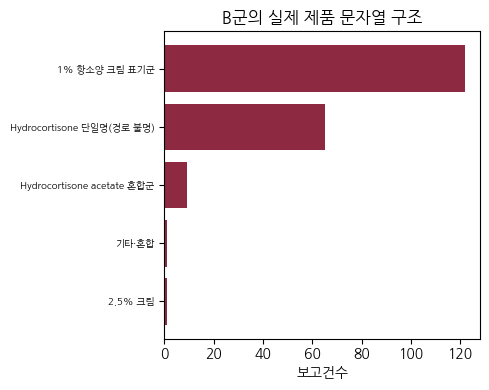

In [11]:

plt.figure(figsize=(5, 4))

plot = cluster_summary.sort_values("보고건수")

plt.barh(
    plot["제품 문자열군"],
    plot["보고건수"],
    color=RED_DARK
)

plt.title("B군의 실제 제품 문자열 구조", fontweight="bold")
plt.xlabel("보고건수")
plt.yticks(fontsize=7)

savefig("01_제품문자열군.png")

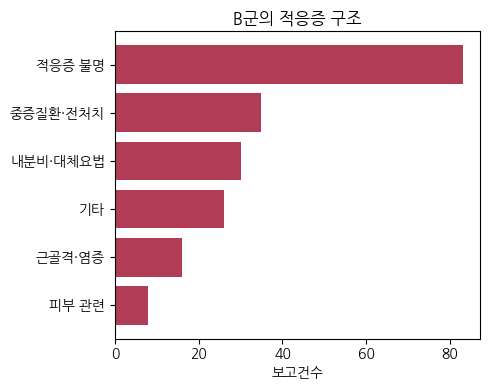

In [12]:
plt.figure(figsize=(5, 4))

plot = indication_summary.sort_values("보고건수")

plt.barh(
    plot["적응증 범주"],
    plot["보고건수"],
    color=RED_MAIN
)

plt.title("B군의 적응증 구조", fontweight="bold")
plt.xlabel("보고건수")

savefig("02_적응증구성.png")

,이상반응,보고건수,비율(%)
0,Drug ineffective,22,11.111111
1,Drug hypersensitivity,14,7.070707
2,Fatigue,12,6.060606
3,Malaise,9,4.545455
4,Pain,8,4.040404
5,Arthralgia,8,4.040404
6,Weight increased,7,3.535354
7,Pruritus,6,3.030303
8,Abdominal discomfort,6,3.030303
9,Dizziness,6,3.030303


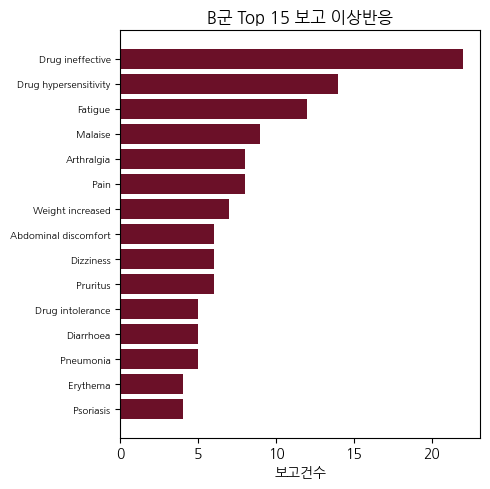

In [13]:
counter = Counter()

for values in b["reaction_list"]:
    counter.update(set(values))

top15 = pd.DataFrame(
    counter.most_common(15),
    columns=["이상반응", "보고건수"]
)

top15["비율(%)"] = top15["보고건수"] / len(b) * 100

display(top15)

plt.figure(figsize=(5, 5))

plot = top15.sort_values("보고건수")

plt.barh(
    plot["이상반응"],
    plot["보고건수"],
    color=BURGUNDY
)

plt.title("B군 Top 15 보고 이상반응", fontweight="bold")
plt.xlabel("보고건수")
plt.yticks(fontsize=7)

savefig("03_Top15_이상반응.png")

,반응군,보고건수,비율(%),95% CI 하한(%),95% CI 상한(%),1% 표기군 비율(%)
0,사용·효과 문제,43,21.717172,16.541802,27.969103,18.852459
1,국소 피부 자극·악화,28,14.141414,9.968596,19.679158,11.475410
2,신경·인지·낙상,26,13.131313,9.121075,18.544925,13.934426
3,전신 스테로이드·내분비,25,12.626263,8.700517,17.974607,9.836066
4,알레르기·과민반응,20,10.101010,6.634369,15.086371,8.196721
5,위장관 증상,18,9.090909,5.827814,13.911172,6.557377
6,감염·면역 관련,17,8.585859,5.429575,13.318535,6.557377
7,심혈관·체액,15,7.575758,4.644480,12.121877,8.196721
8,간 관련,5,2.525253,1.083353,5.774237,3.278689
9,눈 관련,4,2.020202,0.788353,5.078359,0.819672


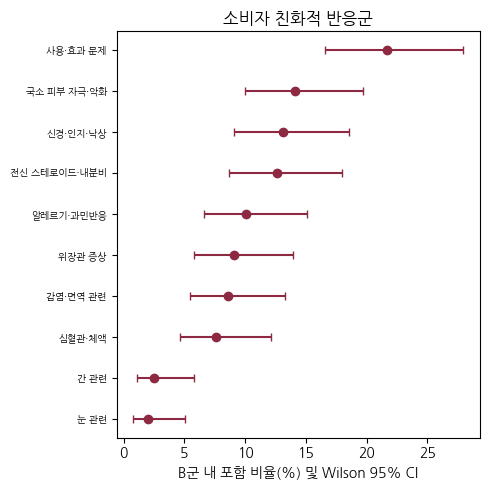

In [14]:
reaction_rows = []

for name in reaction_groups:
    event_count = int(b[name].sum())
    low, high = proportion_confint(
        event_count,
        len(b),
        method="wilson"
    )

    topical_rate = (
        topical_labelled[name].mean() * 100
        if len(topical_labelled) > 0
        else np.nan
    )

    reaction_rows.append({
        "반응군": name,
        "보고건수": event_count,
        "비율(%)": event_count / len(b) * 100,
        "95% CI 하한(%)": low * 100,
        "95% CI 상한(%)": high * 100,
        "1% 표기군 비율(%)": topical_rate,
    })

reaction_summary = (
    pd.DataFrame(reaction_rows)
    .sort_values("비율(%)", ascending=False)
)

display(reaction_summary)




plt.figure(figsize=(5, 5))

plot = reaction_summary.sort_values("비율(%)")
y = np.arange(len(plot))
rates = plot["비율(%)"].to_numpy()

plt.errorbar(
    rates,
    y,
    xerr=[
        rates - plot["95% CI 하한(%)"].to_numpy(),
        plot["95% CI 상한(%)"].to_numpy() - rates,
    ],
    fmt="o",
    capsize=3,
    color=RED_DARK,
)

plt.yticks(y, plot["반응군"], fontsize=7)
plt.xlabel("B군 내 포함 비율(%) 및 Wilson 95% CI")
plt.title("소비자 친화적 반응군", fontweight="bold")

savefig("04_반응군_WilsonCI.png")

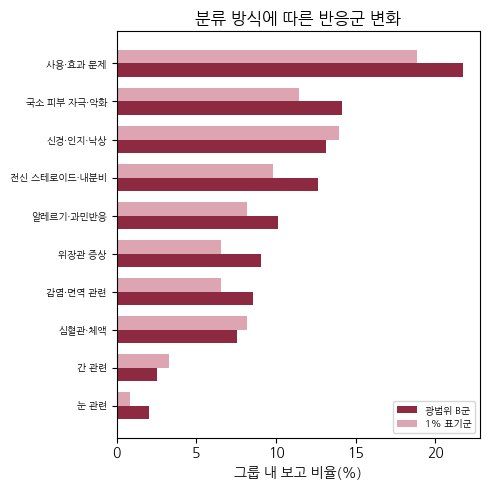

In [15]:

#분류 민감도 비교

plt.figure(figsize=(5, 5))

plot = reaction_summary.sort_values("비율(%)")
y = np.arange(len(plot))

plt.barh(
    y - 0.18,
    plot["비율(%)"],
    0.36,
    label="광범위 B군",
    color=RED_DARK
)

plt.barh(
    y + 0.18,
    plot["1% 표기군 비율(%)"],
    0.36,
    label="1% 표기군",
    color=RED_LIGHT
)

plt.yticks(y, plot["반응군"], fontsize=7)
plt.xlabel("그룹 내 보고 비율(%)")
plt.title("분류 방식에 따른 반응군 변화", fontweight="bold")
plt.legend(fontsize=7)

savefig("05_분류민감도.png")

,연령대,n,serious_건수,serious 비율(%)
0,0–17세,32,30,93.750000
1,18–40세,20,17,85.000000
2,41–64세,67,55,82.089552
3,65세 이상,43,31,72.093023
4,Unknown,36,26,72.222222


serious_bool,False,True
연령대,,
0–17세,2,30
18–40세,3,17
41–64세,12,55
65세 이상,12,31


연령대 × serious 카이제곱 p-value: 0.1116329495697044


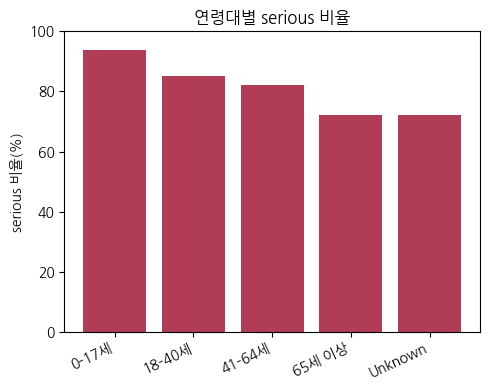

In [16]:
def age_group_func(age):
    if pd.isna(age):
        return "Unknown"
    if age <= 17:
        return "0–17세"
    if age <= 40:
        return "18–40세"
    if age <= 64:
        return "41–64세"
    return "65세 이상"

age_order = ["0–17세", "18–40세", "41–64세", "65세 이상", "Unknown"]

b["연령대"] = b["age_num"].apply(age_group_func)

age_summary = (
    b.groupby("연령대")
    .agg(
        n=("serious_bool", "size"),
        serious_건수=("serious_bool", "sum")
    )
    .reindex(age_order)
    .reset_index()
)

age_summary["serious 비율(%)"] = age_summary["serious_건수"] / age_summary["n"] * 100

display(age_summary)


# 연령대 × serious 카이제곱 검정

known_age = b[b["연령대"] != "Unknown"].copy()

age_table = pd.crosstab(
    known_age["연령대"],
    known_age["serious_bool"]
).reindex(age_order[:-1], fill_value=0)

display(age_table)

if age_table.shape[0] >= 2 and age_table.shape[1] >= 2:
    chi2, age_p, dof, expected = chi2_contingency(age_table)
    print("연령대 × serious 카이제곱 p-value:", age_p)
else:
    age_p = np.nan
    print("연령대 검정 불가")



# 시각화 연령대별 serious 비율

plt.figure(figsize=(5, 4))

plot = age_summary.dropna(subset=["n"])

plt.bar(
    plot["연령대"],
    plot["serious 비율(%)"],
    color=RED_MAIN
)

plt.title("연령대별 serious 비율", fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

savefig("06_연령대별_serious.png")

,sex_clean,n,serious_건수,serious 비율(%)
0,Female,116,89,76.724138
1,Male,72,62,86.111111
2,Unknown,10,8,80.000000


serious_bool,False,True
sex_clean,,
Female,27,89
Male,10,62


성별 × serious Fisher p-value: 0.13364721036761718


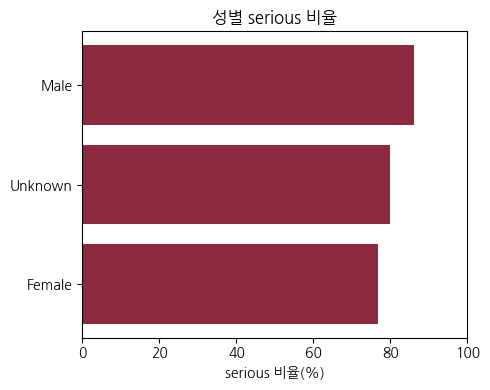

In [17]:

# 성별 분석

sex_summary = (
    b.groupby("sex_clean")
    .agg(
        n=("serious_bool", "size"),
        serious_건수=("serious_bool", "sum")
    )
    .reset_index()
)

sex_summary["serious 비율(%)"] = sex_summary["serious_건수"] / sex_summary["n"] * 100

display(sex_summary)

sex_known = b[b["sex_clean"].isin(["Female", "Male"])].copy()

sex_table = pd.crosstab(
    sex_known["sex_clean"],
    sex_known["serious_bool"]
)

display(sex_table)

if sex_table.shape == (2, 2):
    _, sex_p = fisher_exact(sex_table)
    print("성별 × serious Fisher p-value:", sex_p)
else:
    sex_p = np.nan
    print("성별 검정 불가")





# 시각화 성별 serious 비율


plt.figure(figsize=(5, 4))

plot = sex_summary.sort_values("serious 비율(%)")

plt.barh(
    plot["sex_clean"],
    plot["serious 비율(%)"],
    color=RED_DARK
)

plt.title("성별 serious 비율", fontweight="bold")
plt.xlabel("serious 비율(%)")
plt.xlim(0, 100)

savefig("07_성별_serious.png")


체중 확인 가능: 59
체중 결측: 139
체중 결측률(%): 70.2020202020202


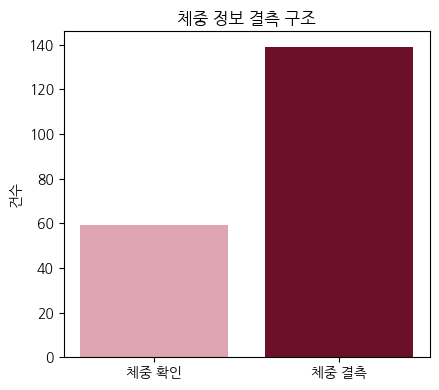

In [18]:
#체중 결측률


weight_known = b["weight_num"].notna().sum()
weight_missing = b["weight_num"].isna().sum()
weight_missing_rate = weight_missing / len(b) * 100

print("체중 확인 가능:", weight_known)
print("체중 결측:", weight_missing)
print("체중 결측률(%):", weight_missing_rate)

plt.figure(figsize=(4.5, 4))

plt.bar(
    ["체중 확인", "체중 결측"],
    [weight_known, weight_missing],
    color=[RED_LIGHT, BURGUNDY]
)

plt.title("체중 정보 결측 구조", fontweight="bold")
plt.ylabel("건수")

savefig("08_체중결측.png")

,보고약물수구간,n,serious_건수,serious 비율(%)
0,2-3 Drugs,44,28,63.636364
1,4-5 Drugs,32,22,68.750000
2,Polypharmacy(6+),98,92,93.877551
3,Single,20,13,65.000000
4,Unknown,4,4,100.000000


serious_bool,False,True
보고약물수구간,,
2-3 Drugs,16,28
4-5 Drugs,10,22
Polypharmacy(6+),6,92
Single,7,13


보고 약물 수 구간 × serious 카이제곱 p-value: 2.053165850909481e-05


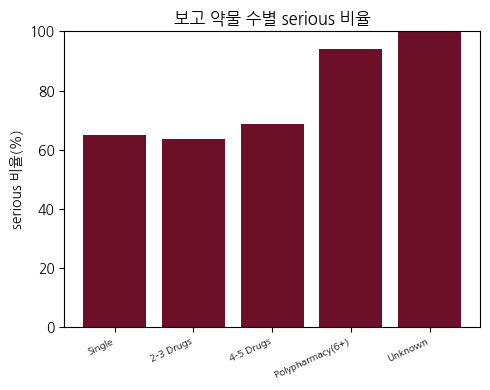

In [19]:
#보고약물수

def drug_count_group(x):
    if pd.isna(x):
        return "Unknown"
    if x == 1:
        return "Single"
    if x <= 3:
        return "2-3 Drugs"
    if x <= 5:
        return "4-5 Drugs"
    if x < 100:
        return "Polypharmacy(6+)"
    return "Extreme/검토필요"

if "drug_count_category" in b.columns:
    b["보고약물수구간"] = b["drug_count_category"].fillna("Unknown").astype(str)
else:
    b["보고약물수구간"] = b["num_drugs_num"].apply(drug_count_group)

drug_order = [
    "Single",
    "2-3 Drugs",
    "4-5 Drugs",
    "Polypharmacy(6+)",
    "Unknown",
    "Extreme/검토필요"
]

drug_summary = (
    b.groupby("보고약물수구간")
    .agg(
        n=("serious_bool", "size"),
        serious_건수=("serious_bool", "sum")
    )
    .reset_index()
)

drug_summary["serious 비율(%)"] = drug_summary["serious_건수"] / drug_summary["n"] * 100

display(drug_summary)




# 보고 약물 수 구간 × serious 검정


known_drug = b[
    b["보고약물수구간"].isin([
        "Single",
        "2-3 Drugs",
        "4-5 Drugs",
        "Polypharmacy(6+)"
    ])
].copy()

drug_table = pd.crosstab(
    known_drug["보고약물수구간"],
    known_drug["serious_bool"]
)

display(drug_table)

if drug_table.shape[0] >= 2 and drug_table.shape[1] >= 2:
    chi2, drug_p, dof, expected = chi2_contingency(drug_table)
    print("보고 약물 수 구간 × serious 카이제곱 p-value:", drug_p)
else:
    drug_p = np.nan
    print("보고 약물 수 검정 불가")




# 시각화.보고 약물 수별 serious 비율

plot = drug_summary.copy()
plot["보고약물수구간"] = pd.Categorical(
    plot["보고약물수구간"],
    categories=drug_order,
    ordered=True
)
plot = plot.sort_values("보고약물수구간")

plt.figure(figsize=(5, 4))

plt.bar(
    plot["보고약물수구간"].astype(str),
    plot["serious 비율(%)"],
    color=BURGUNDY
)

plt.title("보고 약물 수별 serious 비율", fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.xticks(rotation=25, ha="right", fontsize=7)
plt.ylim(0, 100)

savefig("09_보고약물수_serious.png")

In [20]:
# ============================================================
# ROR 계산 함수
# ============================================================

def compute_ror(target_df, reference_df, min_count=5):
    """
    target_df: 관심군, 예: B군
    reference_df: 비교군, 예: D군 나머지
    min_count: target군 내 최소 보고건수
    """
    target_terms = set()
    ref_terms = set()

    for vals in target_df["reaction_list"]:
        target_terms.update(vals)

    for vals in reference_df["reaction_list"]:
        ref_terms.update(vals)

    all_terms = sorted(target_terms.union(ref_terms))

    rows = []

    for term in all_terms:
        a = target_df["reaction_list"].apply(lambda x: term in x).sum()
        b_non = len(target_df) - a
        c = reference_df["reaction_list"].apply(lambda x: term in x).sum()
        d_non = len(reference_df) - c

        if a < min_count:
            continue

        # 0셀 보정
        aa, bb, cc, dd = a, b_non, c, d_non
        if min(aa, bb, cc, dd) == 0:
            aa += 0.5
            bb += 0.5
            cc += 0.5
            dd += 0.5

        ror = (aa / bb) / (cc / dd)
        se = math.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
        ci_low = math.exp(math.log(ror) - 1.96 * se)
        ci_high = math.exp(math.log(ror) + 1.96 * se)

        table = np.array([
            [a, b_non],
            [c, d_non]
        ])

        _, p = fisher_exact(table)

        rows.append({
            "이상반응": term,
            "관심군 건수": int(a),
            "비교군 건수": int(c),
            "ROR": ror,
            "95% CI 하한": ci_low,
            "95% CI 상한": ci_high,
            "p-value": p
        })

    result = pd.DataFrame(rows)

    if len(result) == 0:
        return result

    result["FDR q-value"] = multipletests(
        result["p-value"],
        method="fdr_bh"
    )[1]

    result = result.sort_values("ROR", ascending=False)

    return result


# D군 나머지
d_other = d.loc[~d.index.isin(b.index)].copy()

# 광범위 B군 ROR
ror_b = compute_ror(
    target_df=b,
    reference_df=d_other,
    min_count=5
)

display(ror_b.head(20))

# 유의 신호 기준
sig_ror_b = ror_b[
    (ror_b["95% CI 하한"] > 1) &
    (ror_b["FDR q-value"] < 0.05)
].copy()

display(sig_ror_b)

,이상반응,관심군 건수,비교군 건수,ROR,95% CI 하한,95% CI 상한,p-value,FDR q-value
8,Malaise,9,0,44.467018,2.574868,767.928981,0.000023,0.000287
0,Abdominal discomfort,6,0,29.950649,1.678813,534.330642,0.000824,0.002677
6,Drug intolerance,5,0,25.211886,1.387194,458.219336,0.002715,0.005882
10,Pneumonia,5,0,25.211886,1.387194,458.219336,0.002715,0.005882
2,Diarrhoea,5,1,11.450777,1.328880,98.669813,0.012169,0.015820
7,Fatigue,12,3,9.462366,2.639495,33.921772,0.000104,0.000452
4,Drug hypersensitivity,14,4,8.350543,2.712466,25.707813,0.000044,0.000287
9,Pain,8,3,6.175439,1.620589,23.532215,0.004898,0.007959
1,Arthralgia,8,3,6.175439,1.620589,23.532215,0.004898,0.007959
12,Weight increased,7,3,5.375218,1.375269,21.008959,0.011994,0.015820


,이상반응,관심군 건수,비교군 건수,ROR,95% CI 하한,95% CI 상한,p-value,FDR q-value
8,Malaise,9,0,44.467018,2.574868,767.928981,0.000023,0.000287
0,Abdominal discomfort,6,0,29.950649,1.678813,534.330642,0.000824,0.002677
6,Drug intolerance,5,0,25.211886,1.387194,458.219336,0.002715,0.005882
10,Pneumonia,5,0,25.211886,1.387194,458.219336,0.002715,0.005882
2,Diarrhoea,5,1,11.450777,1.328880,98.669813,0.012169,0.015820
7,Fatigue,12,3,9.462366,2.639495,33.921772,0.000104,0.000452
4,Drug hypersensitivity,14,4,8.350543,2.712466,25.707813,0.000044,0.000287
9,Pain,8,3,6.175439,1.620589,23.532215,0.004898,0.007959
1,Arthralgia,8,3,6.175439,1.620589,23.532215,0.004898,0.007959
12,Weight increased,7,3,5.375218,1.375269,21.008959,0.011994,0.015820


In [21]:
# ============================================================
# 1% 항소양 크림 표기군 ROR
# ============================================================

d_other_topical = d.loc[~d.index.isin(topical_labelled.index)].copy()

ror_topical = compute_ror(
    target_df=topical_labelled,
    reference_df=d_other_topical,
    min_count=3
)

display(ror_topical.head(20))

sig_ror_topical = ror_topical[
    (ror_topical["95% CI 하한"] > 1) &
    (ror_topical["FDR q-value"] < 0.05)
].copy()

display(sig_ror_topical)

,이상반응,관심군 건수,비교군 건수,ROR,95% CI 하한,95% CI 상한,p-value,FDR q-value
3,Clostridium difficile colitis,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
13,Glossodynia,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
5,Discomfort,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
15,Posterior reversible encephalopathy syndrome,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
12,Febrile neutropenia,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
14,Hypertension,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
1,Adrenal insufficiency,3,1,13.058824,1.346485,126.650404,0.023249,0.039523
0,Abdominal discomfort,4,2,8.762712,1.586226,48.407430,0.013732,0.025939
11,Fatigue,8,7,5.132832,1.824219,14.442322,0.002713,0.016411
2,Asthenia,3,3,4.336134,0.864404,21.751463,0.086408,0.125993


,이상반응,관심군 건수,비교군 건수,ROR,95% CI 하한,95% CI 상한,p-value,FDR q-value
3,Clostridium difficile colitis,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
13,Glossodynia,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
5,Discomfort,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
15,Posterior reversible encephalopathy syndrome,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
12,Febrile neutropenia,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
14,Hypertension,3,0,30.430962,1.561356,593.102160,0.006758,0.016411
1,Adrenal insufficiency,3,1,13.058824,1.346485,126.650404,0.023249,0.039523
0,Abdominal discomfort,4,2,8.762712,1.586226,48.407430,0.013732,0.025939
11,Fatigue,8,7,5.132832,1.824219,14.442322,0.002713,0.016411


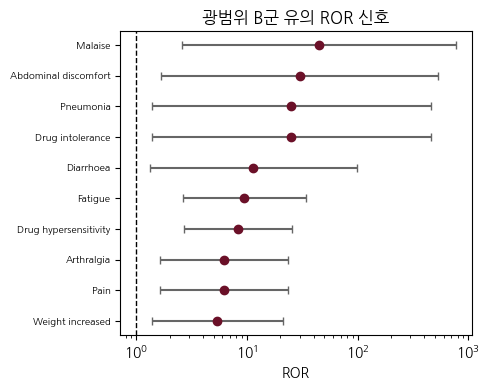

In [22]:
# 시각화. 광범위 B군 유의 ROR

plot = sig_ror_b.head(10).sort_values("ROR")

plt.figure(figsize=(5, 4))

if len(plot) > 0:
    plt.errorbar(
        plot["ROR"],
        np.arange(len(plot)),
        xerr=[
            plot["ROR"] - plot["95% CI 하한"],
            plot["95% CI 상한"] - plot["ROR"]
        ],
        fmt="o",
        color=BURGUNDY,
        ecolor=GRAY,
        capsize=3
    )

    plt.axvline(1, color="black", linestyle="--", linewidth=1)
    plt.yticks(np.arange(len(plot)), plot["이상반응"], fontsize=7)
    plt.xlabel("ROR")
    plt.title("광범위 B군 유의 ROR 신호", fontweight="bold")
    plt.xscale("log")
else:
    plt.text(
        0.5,
        0.5,
        "유의한 ROR 신호 없음",
        ha="center",
        va="center"
    )
    plt.axis("off")

savefig("10_ROR_광범위B군.png")